# DDPM Condicional — versión arquitectura literal del paper

**Referencia**: Lee, B. H. *et al.* (2025) *Thermodynamic Fidelity of Generative Models for Ising System*.

Réplica fiel de la U-Net descrita en la Fig. 1c del paper, adaptada solo en lo siguiente:
- Vector de condición de **8 parámetros físicos** (en lugar de 1 temperatura).
- Imágenes 39×39 con **padding reflect → 40×40** (en lugar de 64×64 binario), y **crop 40→39** a la salida para no perder información en las métricas.
- Mismas seeds, splits, subsample, batch, lr, schedule β y T=1000 que mi notebook anterior, para comparar 1:1.

**Arquitectura U-Net (literal del paper)**:
- 4 niveles de feature map: `40 → 20 → 10 → 5` (en el paper: 64→32→16→8)
- Canales por nivel: `64 → 128 → 256 → 512` (bottleneck)
- *Double Conv2d* = `Conv → GroupNorm → GELU → Conv → GroupNorm` (sin skip residual)
- Embedding `(t, T)` reshape a `(B,1,H,W)` y **sumado al feature map** en cada nivel
- **Self-attention** en los dos niveles más profundos (10×10 y 5×5)
- MaxPool 2×2 para downsample, Upsample 2×2 para subir, copy layer (concat) para skips


## 1. Instalaciones e imports

In [1]:
# pytorch-msssim para SSIM equivalente al CVAE
!pip install pytorch-msssim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 68.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
import os
import json
import time
import pickle
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from pytorch_msssim import ssim as ssim_fn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch:  {torch.__version__}")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch:  2.10.0+cu128
Dispositivo: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Hiperparámetros

Idénticos a mi notebook anterior para que la comparación sea justa.

In [3]:
# ─── Datos ───────────────────────────────────────────────────
DATASET_PATH   = "/kaggle/input/datasets/carloscanamejoy/dataset-spines-united-v2/dataset_unificado_v2.npz"
SUBSAMPLE_FRAC = 0.10      # igual que el CVAE y el DDPM v1
ORIG_SIZE      = 39        # tamaño nativo de las imágenes
IMG_SIZE       = 40        # tamaño tras padding reflect (divisible por 2 dos veces)
COND_DIM       = 8         # dimensión de los parámetros físicos

# ─── Difusión ────────────────────────────────────────────────
T_STEPS        = 1000      # pasos de ruido DDPM estándar (= paper)
BETA_START     = 1e-4      # schedule lineal de betas (= paper)
BETA_END       = 0.02

# ─── Entrenamiento ───────────────────────────────────────────
EPOCHS         = 50        # igual a mi notebook v1 (paper usa 300, pero
                           # subsample y comparabilidad lo justifican)
BATCH_SIZE     = 64
LR             = 2e-4
GRAD_CLIP      = 1.0

# ─── U-Net (literal del paper, Fig. 1c) ──────────────────────
# Canales: 64 → 128 → 256 → 512 (bottleneck)
BASE_CH        = 64
CH_MULTS       = (1, 2, 4, 8)   # 4 niveles, igual al paper
COND_EMB_DIM   = 128
GROUPS         = 8

# ─── Guardado ────────────────────────────────────────────────
CKPT_PATH      = "/kaggle/working/ddpm_spines_paper_best.pt"
LAST_PATH      = "/kaggle/working/ddpm_spines_paper_last.pt"

print("Hiperparámetros cargados")
print(f"  SUBSAMPLE: {SUBSAMPLE_FRAC*100:.0f}%")
print(f"  ORIG_SIZE → IMG_SIZE:  {ORIG_SIZE} → {IMG_SIZE}  (pad reflect)")
print(f"  EPOCHS:    {EPOCHS}")
print(f"  BATCH:     {BATCH_SIZE}")
print(f"  T_STEPS:   {T_STEPS}")
print(f"  BASE_CH:   {BASE_CH}  |  CH_MULTS: {CH_MULTS}")

Hiperparámetros cargados
  SUBSAMPLE: 10%
  ORIG_SIZE → IMG_SIZE:  39 → 40  (pad reflect)
  EPOCHS:    50
  BATCH:     64
  T_STEPS:   1000
  BASE_CH:   64  |  CH_MULTS: (1, 2, 4, 8)


## 3. Cargar datos

**Mismo split, semillas y subsample** que mi notebook v1.

In [4]:
data   = np.load(DATASET_PATH)
imgs   = data["img"].astype(np.float32)    # (N, H, W, 1) o (N, H, W)
params = data["params"].astype(np.float32) # (N, 8)

# Asegurar forma (N, H, W, 1)
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]

N = len(imgs)
print(f"Dataset total: {N:,}  |  imgs: {imgs.shape}  |  params: {params.shape}")
print(f"  imgs rango:   [{imgs.min():.2f}, {imgs.max():.2f}]")

# Subsample — mismo RandomState que v1
rng     = np.random.RandomState(SEED)
sub_idx = rng.choice(N, size=int(N * SUBSAMPLE_FRAC), replace=False)
imgs_s  = imgs[sub_idx]
params_s = params[sub_idx]

# Split idéntico (70 / 15 / 15)
idx_all = np.arange(len(sub_idx))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)

# Normalizar parámetros (fit solo en train)
scaler = MinMaxScaler()
p_train = scaler.fit_transform(params_s[idx_train]).astype(np.float32)
p_val   = scaler.transform(params_s[idx_val]).astype(np.float32)
p_test  = scaler.transform(params_s[idx_test]).astype(np.float32)

print(f"Train: {len(idx_train):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}")

Dataset total: 169,671  |  imgs: (169671, 39, 39, 1)  |  params: (169671, 8)
  imgs rango:   [-1.00, 1.00]
Train: 11,876  Val: 2,545  Test: 2,546


## 4. Dataset PyTorch — **padding reflect**, NO resize

Cambio clave respecto al notebook v1: en vez de `F.interpolate(mode='bilinear')` para llevar
39×39 → 40×40 (que distorsiona los valores), aplico `F.pad(..., mode='reflect')` con padding 1
píxel a la derecha y abajo. El modelo trabaja internamente con 40×40 y a la salida cropearemos
los primeros 39×39 píxeles para recuperar la imagen sin pérdida.

In [5]:
class SpinesDataset(Dataset):
    """
    Devuelve imagen 40×40 en [-1, 1] (pad reflect desde 39×39) y parámetros normalizados.
    Guarda también la imagen 39×39 original para referencia en métricas.
    """

    def __init__(self, imgs_arr, params_arr, orig_size=39, img_size=40):
        # imgs_arr: (N, H, W, 1) float32 en rango original
        imgs_t = torch.from_numpy(imgs_arr).permute(0, 3, 1, 2)  # (N,1,H,W)

        # Si el tamaño nativo no coincide con orig_size, resize (caso borde)
        if imgs_t.shape[-1] != orig_size or imgs_t.shape[-2] != orig_size:
            imgs_t = F.interpolate(imgs_t, size=(orig_size, orig_size),
                                   mode='bilinear', align_corners=False)

        # Normalizar a [-1, 1] sobre las imágenes 39×39 originales
        mn, mx = imgs_t.min(), imgs_t.max()
        imgs_t = (imgs_t - mn) / (mx - mn + 1e-8)   # [0,1]
        imgs_t = imgs_t * 2.0 - 1.0                  # [-1,1]

        # Guardar original 39×39 (para métricas y crop a la salida)
        self.imgs_orig = imgs_t.float()              # (N,1,39,39)

        # Padding reflect a 40×40: pad (left=0, right=1, top=0, bottom=1)
        pad = img_size - orig_size                   # = 1
        self.imgs = F.pad(imgs_t, (0, pad, 0, pad), mode='reflect').float()  # (N,1,40,40)

        self.params = torch.from_numpy(params_arr).float()

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        return self.imgs[i], self.params[i]


ds_train = SpinesDataset(imgs_s[idx_train], p_train, ORIG_SIZE, IMG_SIZE)
ds_val   = SpinesDataset(imgs_s[idx_val],   p_val,   ORIG_SIZE, IMG_SIZE)
ds_test  = SpinesDataset(imgs_s[idx_test],  p_test,  ORIG_SIZE, IMG_SIZE)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

# Verificar
x0, y0 = next(iter(dl_train))
print(f"Batch imagen (40×40): {x0.shape}  rango [{x0.min():.2f}, {x0.max():.2f}]")
print(f"Batch params:         {y0.shape}  rango [{y0.min():.2f}, {y0.max():.2f}]")
print(f"Imagen original 39×39 guardada en ds.imgs_orig: {ds_train.imgs_orig.shape}")

Batch imagen (40×40): torch.Size([64, 1, 40, 40])  rango [-1.00, 1.00]
Batch params:         torch.Size([64, 8])  rango [0.00, 1.00]
Imagen original 39×39 guardada en ds.imgs_orig: torch.Size([11876, 1, 39, 39])


## 5. Schedule de ruido DDPM

Idéntico a v1 — schedule lineal de β como en Ho et al. 2020 y como en el paper.

In [6]:
class DDPMScheduler:
    """
    Schedule lineal de betas para DDPM (Ho et al. 2020 / Lee et al. 2025).
    Precalcula alphas acumulados para el forward process eficiente.
    """

    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T = T
        betas = torch.linspace(beta_start, beta_end, T, device=device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        self.sqrt_alphas_cumprod     = alphas_cumprod.sqrt()
        self.sqrt_one_minus_alphas_cumprod = (1.0 - alphas_cumprod).sqrt()
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
        self.posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.sqrt_recip_alphas  = (1.0 / alphas).sqrt()
        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod

    def q_sample(self, x0, t, noise=None):
        """Forward process: x_t = sqrt(ᾱ_t)*x0 + sqrt(1-ᾱ_t)*ε"""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_a  = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_1a = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_a * x0 + sqrt_1a * noise, noise

    @torch.no_grad()
    def p_sample_step(self, model, x_t, t_scalar, cond):
        """Un paso del reverse process DDPM."""
        B = x_t.shape[0]
        t_tensor = torch.full((B,), t_scalar, device=x_t.device, dtype=torch.long)
        eps_pred = model(x_t, t_tensor, cond)
        beta_t    = self.betas[t_scalar]
        sqrt_ra   = self.sqrt_recip_alphas[t_scalar]
        sqrt_1ma  = self.sqrt_one_minus_alphas_cumprod[t_scalar]
        mean = sqrt_ra * (x_t - beta_t / sqrt_1ma * eps_pred)
        if t_scalar > 0:
            z = torch.randn_like(x_t)
            sigma = self.posterior_variance[t_scalar].sqrt()
            return mean + sigma * z
        return mean

    @torch.no_grad()
    def sample(self, model, cond, img_size=40, channels=1):
        """Generación completa: x_T ~ N(0,I) → x_0"""
        B = cond.shape[0]
        x = torch.randn(B, channels, img_size, img_size, device=cond.device)
        for t in reversed(range(self.T)):
            x = self.p_sample_step(model, x, t, cond)
        return x


scheduler = DDPMScheduler(T=T_STEPS, beta_start=BETA_START, beta_end=BETA_END, device=DEVICE)
print(f"Schedule OK — T={T_STEPS}, β: {BETA_START}→{BETA_END}")
print(f"  ᾱ_0 = {scheduler.alphas_cumprod[0]:.4f}")
print(f"  ᾱ_T = {scheduler.alphas_cumprod[-1]:.4f}")

Schedule OK — T=1000, β: 0.0001→0.02
  ᾱ_0 = 0.9999
  ᾱ_T = 0.0000


## 6. U-Net — réplica literal del paper

Componentes (Lee et al. 2025, sección 2.3 y Fig. 1c–d):
- **Embedding de tiempo**: positional encoding sinusoidal (Vaswani et al.).
- **Embedding de condición**: MLP de 2 capas con ReLU. Cambio: dimensión de entrada `8` (8 parámetros físicos) en lugar de `1` (temperatura escalar del paper).
- **Fusión**: suma `t_emb + T_emb` → `SiLU` → `linear` → `reshape a (B,1,H,W)` → **sumado al feature map** en cada nivel del U-Net. Cada nivel tiene su propia capa lineal porque el tamaño espacial cambia.
- **Double Conv2d**: `Conv2d → GroupNorm → GELU → Conv2d → GroupNorm` (sin skip residual interno — esto distingue al paper de las implementaciones modernas con ResBlocks).
- **Self-attention**: aplicado en los dos niveles más profundos (10×10 y 5×5, equivalente a 16×16 y 8×8 del paper para 64×64).
- **Downsample**: `MaxPool2d(2)`. **Upsample**: `nn.Upsample(scale=2, mode='nearest')`.
- **Skip connections**: concatenación (copy layer) tipo U-Net clásica.
- **Bottleneck (5×5)**: tres Double Conv2d con expansión 256 → 512 → 256 (refleja la secuencia de la Fig. 1c).

In [7]:
# ── Utilidades de embedding ─────────────────────────────────────────

def sinusoidal_embedding(t, dim):
    """PE sinusoidal de Vaswani et al. — eq. 7 del paper."""
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1)
    )
    args = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class TimeCondEmbedding(nn.Module):
    """
    Réplica de Fig. 1d:
      t  → PE sinusoidal → [t1..td]
      T  → 2-layer NN (ReLU) → [T1..Td]   (en nuestro caso 8 params)
      [t + T] → SiLU → Linear → vector emb_dim
    """
    def __init__(self, emb_dim, cond_dim=8):
        super().__init__()
        self.emb_dim = emb_dim
        # Embedding de la condición: 2-layer NN con ReLU (paper)
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
        )
        # Salida: SiLU + linear (paper)
        self.out = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )

    def forward(self, t, cond):
        t_emb = sinusoidal_embedding(t, self.emb_dim)
        c_emb = self.cond_mlp(cond)
        return self.out(t_emb + c_emb)


class EmbInject(nn.Module):
    """
    Reshape el embedding al tamaño del feature map y súmalo elemento a elemento.
    El paper dice: 'reshaped into the image dimension to be added to the image in
    each layer of UNET'. Cada nivel tiene su propia capa lineal porque H×W cambia.
    """
    def __init__(self, emb_dim, h, w):
        super().__init__()
        self.h, self.w = h, w
        self.proj = nn.Linear(emb_dim, h * w)

    def forward(self, x, emb):
        # emb: (B, emb_dim) → (B, 1, H, W) → broadcast a todos los canales
        p = self.proj(emb).view(-1, 1, self.h, self.w)
        return x + p


# ── Bloque Double Conv2d (sin skip residual interno) ───────────────────

class DoubleConv(nn.Module):
    """
    Double Conv2d del paper:
      Conv2d → GroupNorm → GELU → Conv2d → GroupNorm
    SIN skip residual interno (a diferencia de ResBlocks modernos).
    """
    def __init__(self, in_ch, out_ch, groups=GROUPS):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(groups, out_ch)

    def forward(self, x):
        x = self.conv1(x)
        x = self.norm1(x)
        x = F.gelu(x)
        x = self.conv2(x)
        x = self.norm2(x)
        return x


# ── Self-attention ──────────────────────────────────────────────────────

class SelfAttention(nn.Module):
    """Atención 1-head sobre feature maps pequeños (igual que v1)."""
    def __init__(self, ch, groups=GROUPS):
        super().__init__()
        self.norm = nn.GroupNorm(groups, ch)
        self.qkv  = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        q, k, v = self.qkv(h).chunk(3, dim=1)
        q = q.reshape(B, C, -1)
        k = k.reshape(B, C, -1)
        v = v.reshape(B, C, -1)
        attn = torch.softmax(torch.bmm(q.transpose(1, 2), k) / math.sqrt(C), dim=-1)
        out  = torch.bmm(v, attn.transpose(1, 2)).reshape(B, C, H, W)
        return x + self.proj(out)


# ── U-Net del paper ─────────────────────────────────────────────────────

class PaperUNet(nn.Module):
    """
    Réplica literal de la U-Net descrita en Lee et al. 2025 (Fig 1c).
    Resoluciones:  40 → 20 → 10 → 5  (paper: 64 → 32 → 16 → 8)
    Canales:       64 → 128 → 256 → 512
    """
    def __init__(self, img_channels=1, cond_dim=8, base_ch=64,
                 ch_mults=(1, 2, 4, 8), emb_dim=128, groups=GROUPS, img_size=40):
        super().__init__()
        self.emb_head = TimeCondEmbedding(emb_dim, cond_dim)

        # Resoluciones por nivel
        H = [img_size // (2**i) for i in range(len(ch_mults))]  # [40, 20, 10, 5]
        C = [base_ch * m for m in ch_mults]                     # [64,128,256,512]

        # Conv de entrada
        self.conv_in = nn.Conv2d(img_channels, C[0], 3, padding=1)

        # ── Encoder ──
        # Nivel 0 (40×40, 64ch)
        self.e0_e1 = EmbInject(emb_dim, H[0], H[0])
        self.e0_c1 = DoubleConv(C[0], C[0], groups)
        self.e0_e2 = EmbInject(emb_dim, H[0], H[0])
        self.e0_c2 = DoubleConv(C[0], C[0], groups)
        self.pool0 = nn.MaxPool2d(2)

        # Nivel 1 (20×20, 64→128)
        self.e1_e1 = EmbInject(emb_dim, H[1], H[1])
        self.e1_c1 = DoubleConv(C[0], C[0], groups)
        self.e1_e2 = EmbInject(emb_dim, H[1], H[1])
        self.e1_c2 = DoubleConv(C[0], C[1], groups)
        self.pool1 = nn.MaxPool2d(2)

        # Nivel 2 (10×10, 128→256, con self-attention)
        self.e2_e1 = EmbInject(emb_dim, H[2], H[2])
        self.e2_c1 = DoubleConv(C[1], C[1], groups)
        self.e2_a1 = SelfAttention(C[1], groups)
        self.e2_e2 = EmbInject(emb_dim, H[2], H[2])
        self.e2_c2 = DoubleConv(C[1], C[2], groups)
        self.e2_a2 = SelfAttention(C[2], groups)
        self.pool2 = nn.MaxPool2d(2)

        # ── Bottleneck (5×5, 256→512→256) ──
        self.m_e1 = EmbInject(emb_dim, H[3], H[3])
        self.m_c1 = DoubleConv(C[2], C[2], groups)
        self.m_a1 = SelfAttention(C[2], groups)
        self.m_e2 = EmbInject(emb_dim, H[3], H[3])
        self.m_c2 = DoubleConv(C[2], C[3], groups)
        self.m_a2 = SelfAttention(C[3], groups)
        self.m_e3 = EmbInject(emb_dim, H[3], H[3])
        self.m_c3 = DoubleConv(C[3], C[2], groups)
        self.m_a3 = SelfAttention(C[2], groups)

        # ── Decoder ──
        # Nivel 2 (10×10, con self-attention)
        self.up2   = nn.Upsample(scale_factor=2, mode='nearest')
        self.d2_e1 = EmbInject(emb_dim, H[2], H[2])
        self.d2_c1 = DoubleConv(C[2] + C[2], C[3], groups)   # cat con skip
        self.d2_a1 = SelfAttention(C[3], groups)
        self.d2_e2 = EmbInject(emb_dim, H[2], H[2])
        self.d2_c2 = DoubleConv(C[3], C[1], groups)
        self.d2_a2 = SelfAttention(C[1], groups)

        # Nivel 1 (20×20)
        self.up1   = nn.Upsample(scale_factor=2, mode='nearest')
        self.d1_e1 = EmbInject(emb_dim, H[1], H[1])
        self.d1_c1 = DoubleConv(C[1] + C[1], C[2], groups)
        self.d1_e2 = EmbInject(emb_dim, H[1], H[1])
        self.d1_c2 = DoubleConv(C[2], C[0], groups)

        # Nivel 0 (40×40)
        self.up0   = nn.Upsample(scale_factor=2, mode='nearest')
        self.d0_e1 = EmbInject(emb_dim, H[0], H[0])
        self.d0_c1 = DoubleConv(C[0] + C[0], C[1], groups)
        self.d0_e2 = EmbInject(emb_dim, H[0], H[0])
        self.d0_c2 = DoubleConv(C[1], C[0], groups)

        # Salida
        self.norm_out = nn.GroupNorm(groups, C[0])
        self.conv_out = nn.Conv2d(C[0], img_channels, 1)

    def forward(self, x, t, cond):
        emb = self.emb_head(t, cond)

        h = self.conv_in(x)

        # Encoder
        h = self.e0_e1(h, emb); h = self.e0_c1(h)
        h = self.e0_e2(h, emb); h = self.e0_c2(h)
        s0 = h;  h = self.pool0(h)

        h = self.e1_e1(h, emb); h = self.e1_c1(h)
        h = self.e1_e2(h, emb); h = self.e1_c2(h)
        s1 = h;  h = self.pool1(h)

        h = self.e2_e1(h, emb); h = self.e2_c1(h); h = self.e2_a1(h)
        h = self.e2_e2(h, emb); h = self.e2_c2(h); h = self.e2_a2(h)
        s2 = h;  h = self.pool2(h)

        # Bottleneck
        h = self.m_e1(h, emb); h = self.m_c1(h); h = self.m_a1(h)
        h = self.m_e2(h, emb); h = self.m_c2(h); h = self.m_a2(h)
        h = self.m_e3(h, emb); h = self.m_c3(h); h = self.m_a3(h)

        # Decoder
        h = self.up2(h)
        h = torch.cat([h, s2], dim=1)
        h = self.d2_e1(h, emb); h = self.d2_c1(h); h = self.d2_a1(h)
        h = self.d2_e2(h, emb); h = self.d2_c2(h); h = self.d2_a2(h)

        h = self.up1(h)
        h = torch.cat([h, s1], dim=1)
        h = self.d1_e1(h, emb); h = self.d1_c1(h)
        h = self.d1_e2(h, emb); h = self.d1_c2(h)

        h = self.up0(h)
        h = torch.cat([h, s0], dim=1)
        h = self.d0_e1(h, emb); h = self.d0_c1(h)
        h = self.d0_e2(h, emb); h = self.d0_c2(h)

        # Salida
        h = self.norm_out(h)
        h = F.gelu(h)
        return self.conv_out(h)


# Instanciar
model = PaperUNet(
    img_channels=1,
    cond_dim=COND_DIM,
    base_ch=BASE_CH,
    ch_mults=CH_MULTS,
    emb_dim=COND_EMB_DIM,
    groups=GROUPS,
    img_size=IMG_SIZE,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net (paper-style) — parámetros entrenables: {n_params:,} ({n_params/1e6:.2f}M)")

# Smoke test
with torch.no_grad():
    _x = torch.randn(4, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _t = torch.randint(0, T_STEPS, (4,)).to(DEVICE)
    _c = torch.rand(4, COND_DIM).to(DEVICE)
    _out = model(_x, _t, _c)
    print(f"Output shape: {_out.shape}  ✓")

del _x, _t, _c, _out

U-Net (paper-style) — parámetros entrenables: 19,507,932 (19.51M)
Output shape: torch.Size([4, 1, 40, 40])  ✓


## 7. Funciones de pérdida y métricas

- **Loss DDPM**: idéntica a v1 — `||ε − ε_θ(x_t, t, y)||²` aplicada sobre las imágenes 40×40 paddadas. El modelo aprende a denoise toda la región 40×40 (incluyendo el píxel reflect).
- **Métricas (MAE, MSE, SSIM)**: se calculan sobre el **crop 39×39** del output contra la imagen original 39×39, para no inflar/contaminar las métricas con la región paddada artificial.

In [8]:
def ddpm_loss(model, x0, cond, scheduler):
    """Loss DDPM estándar (igual que v1, igual que el paper)."""
    B = x0.shape[0]
    t = torch.randint(0, scheduler.T, (B,), device=x0.device)
    noise = torch.randn_like(x0)
    x_t, noise_added = scheduler.q_sample(x0, t, noise)
    eps_pred = model(x_t, t, cond)
    return F.mse_loss(eps_pred, noise_added)


def crop_to_orig(x, orig=ORIG_SIZE):
    """Crop el feature map 40×40 → 39×39 (recupera la imagen sin pérdida)."""
    return x[..., :orig, :orig]


@torch.no_grad()
def compute_metrics(x_gen, x_real):
    """
    Métricas calculadas sobre la región original 39×39 (crop ambos).
    Entrada: tensores en [-1, 1], shape (B, 1, IMG_SIZE, IMG_SIZE) o (B, 1, ORIG_SIZE, ORIG_SIZE).
    """
    # Asegurar crop a 39×39 si vienen en 40×40
    if x_gen.shape[-1] != ORIG_SIZE:
        x_gen = crop_to_orig(x_gen)
    if x_real.shape[-1] != ORIG_SIZE:
        x_real = crop_to_orig(x_real)

    mae  = (x_gen - x_real).abs().mean().item()
    mse  = ((x_gen - x_real) ** 2).mean().item()
    x_g01 = (x_gen  + 1.0) / 2.0
    x_r01 = (x_real + 1.0) / 2.0
    # SSIM con win_size=7 (default) requiere imagen ≥ 7. 39 OK.
    ssim_val = ssim_fn(x_g01, x_r01, data_range=1.0, size_average=True).item()
    return mae, mse, ssim_val


print("Funciones de pérdida y métricas definidas (métricas sobre crop 39×39)")

Funciones de pérdida y métricas definidas (métricas sobre crop 39×39)


## 8. Validación rápida con muestreo parcial

Idéntico a v1: muestreo DDIM-like con 100 pasos para no esperar 1000 pasos en cada validación.
La salida es 40×40; las métricas hacen crop a 39×39 internamente.

In [9]:
@torch.no_grad()
def fast_sample(model, cond, scheduler, n_steps=100, img_size=IMG_SIZE):
    """Muestreo acelerado para validación (igual que v1)."""
    B = cond.shape[0]
    x = torch.randn(B, 1, img_size, img_size, device=cond.device)

    timesteps = list(range(0, scheduler.T, scheduler.T // n_steps))[::-1]

    for t_val in timesteps:
        t_tensor = torch.full((B,), t_val, device=cond.device, dtype=torch.long)
        eps_pred  = model(x, t_tensor, cond)

        sqrt_a    = scheduler.sqrt_alphas_cumprod[t_val]
        sqrt_1a   = scheduler.sqrt_one_minus_alphas_cumprod[t_val]
        x0_pred   = (x - sqrt_1a * eps_pred) / sqrt_a
        x0_pred   = x0_pred.clamp(-1, 1)

        if t_val > 0:
            t_prev = max(t_val - scheduler.T // n_steps, 0)
            sqrt_a_prev  = scheduler.sqrt_alphas_cumprod[t_prev]
            sqrt_1a_prev = scheduler.sqrt_one_minus_alphas_cumprod[t_prev]
            x = sqrt_a_prev * x0_pred + sqrt_1a_prev * eps_pred
        else:
            x = x0_pred
    return x


print("Fast sampler OK")

Fast sampler OK


## 9. Training loop

Idéntico a v1. Solo las métricas son sobre 39×39 cropeado.

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# LR constante (fiel a Ho et al. 2020 y a los papers Lee/Jha)

scaler_amp = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

hist = {
    'train_loss': [],
    'val_loss': [],
    'val_mae': [],
    'val_mse': [],
    'val_ssim': [],
    'lr': [],
}

best_val_ssim = -1.0

VAL_SAMPLE_BATCHES = 4
VAL_FAST_STEPS     = 100

print(f"{'='*70}")
print(f"Entrenando DDPM (paper-style) — U-Net {n_params/1e6:.1f}M params")
print(f"  EPOCHS={EPOCHS}  BATCH={BATCH_SIZE}  LR={LR}  T={T_STEPS}")
print(f"  Batches/época: {len(dl_train)}")
print(f"  Dispositivo: {DEVICE}")
print(f"{'='*70}")

t_global = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── TRAIN ────────────────────────────────────────────────────────────
    model.train()
    train_losses = []

    for x0, cond in dl_train:
        x0   = x0.to(DEVICE, non_blocking=True)
        cond = cond.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            loss = ddpm_loss(model, x0, cond, scheduler)

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)

    # ── VALIDATION ───────────────────────────────────────────────────────
    model.eval()
    val_losses  = []
    maes, mses, ssims = [], [], []

    for i, (x0, cond) in enumerate(dl_val):
        x0   = x0.to(DEVICE, non_blocking=True)
        cond = cond.to(DEVICE, non_blocking=True)

        with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            val_l = ddpm_loss(model, x0, cond, scheduler)
        val_losses.append(val_l.item())

        if i < VAL_SAMPLE_BATCHES:
            x_gen = fast_sample(model, cond, scheduler,
                                n_steps=VAL_FAST_STEPS, img_size=IMG_SIZE)
            # compute_metrics aplica crop 40→39 internamente
            mae, mse, s = compute_metrics(x_gen, x0)
            maes.append(mae); mses.append(mse); ssims.append(s)

    val_loss  = np.mean(val_losses)
    val_mae   = np.mean(maes)
    val_mse   = np.mean(mses)
    val_ssim  = np.mean(ssims)

    current_lr = optimizer.param_groups[0]['lr']

    hist['train_loss'].append(train_loss)
    hist['val_loss'].append(val_loss)
    hist['val_mae'].append(val_mae)
    hist['val_mse'].append(val_mse)
    hist['val_ssim'].append(val_ssim)
    hist['lr'].append(current_lr)

    tag = ""
    if val_ssim > best_val_ssim:
        best_val_ssim = val_ssim
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'val_ssim': val_ssim}, CKPT_PATH)
        tag = " ★"

    elapsed = time.time() - t0
    print(f"Ep[{epoch:3d}/{EPOCHS}]  "
          f"loss={train_loss:.4f}  val={val_loss:.4f}  "
          f"SSIM={val_ssim:.4f}  MAE={val_mae:.4f}  "
          f"lr={current_lr:.1e}  {elapsed:.0f}s{tag}")

torch.save({'epoch': EPOCHS, 'model': model.state_dict()}, LAST_PATH)

total_min = (time.time() - t_global) / 60
print(f"\n{'='*70}")
print(f"Entrenamiento completado en {total_min:.1f} min")
print(f"Mejor SSIM val: {best_val_ssim:.4f}")
print(f"Guardado: {CKPT_PATH}")

Entrenando DDPM (paper-style) — U-Net 19.5M params
  EPOCHS=50  BATCH=64  LR=0.0002  T=1000
  Batches/época: 185
  Dispositivo: cuda


/tmp/ipykernel_23/185464.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
/tmp/ipykernel_23/185464.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_23/185464.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Ep[  1/50]  loss=0.1351  val=0.0826  SSIM=0.0215  MAE=0.4039  lr=2.0e-04  54s ★
Ep[  2/50]  loss=0.0787  val=0.0786  SSIM=0.0169  MAE=0.4310  lr=2.0e-04  60s
Ep[  3/50]  loss=0.0705  val=0.0730  SSIM=0.0076  MAE=0.4713  lr=2.0e-04  64s
Ep[  4/50]  loss=0.0678  val=0.0632  SSIM=0.0218  MAE=0.4362  lr=2.0e-04  64s ★
Ep[  5/50]  loss=0.0640  val=0.0676  SSIM=0.0097  MAE=0.4585  lr=2.0e-04  64s
Ep[  6/50]  loss=0.0632  val=0.0628  SSIM=0.0185  MAE=0.4730  lr=2.0e-04  63s
Ep[  7/50]  loss=0.0634  val=0.0610  SSIM=0.0172  MAE=0.4829  lr=2.0e-04  63s
Ep[  8/50]  loss=0.0645  val=0.0621  SSIM=0.0024  MAE=0.4932  lr=2.0e-04  64s
Ep[  9/50]  loss=0.0626  val=0.0617  SSIM=0.0168  MAE=0.4793  lr=2.0e-04  64s
Ep[ 10/50]  loss=0.0609  val=0.0585  SSIM=0.0202  MAE=0.4822  lr=2.0e-04  64s
Ep[ 11/50]  loss=0.0638  val=0.0610  SSIM=0.0097  MAE=0.4483  lr=2.0e-04  64s
Ep[ 12/50]  loss=0.0612  val=0.0606  SSIM=0.0241  MAE=0.4814  lr=2.0e-04  64s ★
Ep[ 13/50]  loss=0.0617  val=0.0606  SSIM=0.0071  MAE=0.48

## 10. Curvas de entrenamiento

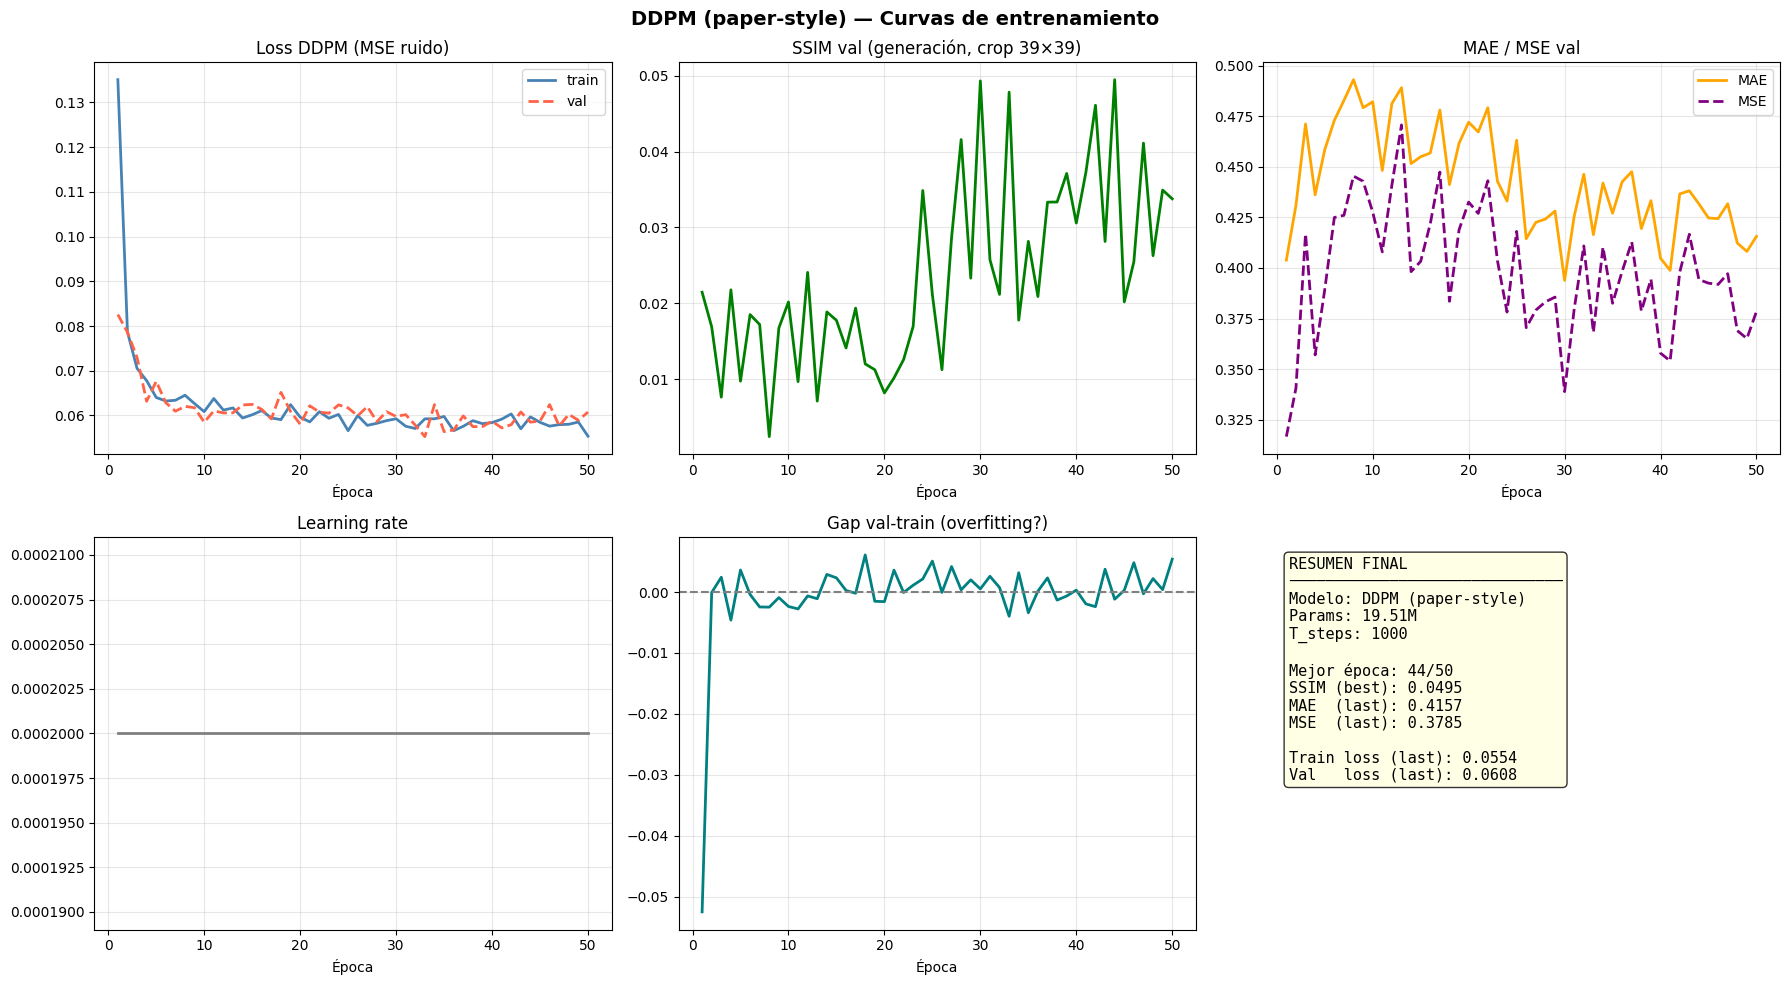

Curvas guardadas


In [11]:
ep = range(1, len(hist['train_loss']) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("DDPM (paper-style) — Curvas de entrenamiento", fontsize=14, fontweight='bold')

axes[0, 0].plot(ep, hist['train_loss'], color='steelblue', lw=2, label='train')
axes[0, 0].plot(ep, hist['val_loss'],   color='tomato',    lw=2, label='val',   ls='--')
axes[0, 0].set_title('Loss DDPM (MSE ruido)'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlabel('Época')

axes[0, 1].plot(ep, hist['val_ssim'], color='green', lw=2)
axes[0, 1].set_title('SSIM val (generación, crop 39×39)'); axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xlabel('Época')

axes[0, 2].plot(ep, hist['val_mae'], color='orange', lw=2, label='MAE')
axes[0, 2].plot(ep, hist['val_mse'], color='purple', lw=2, label='MSE', ls='--')
axes[0, 2].set_title('MAE / MSE val'); axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)
axes[0, 2].set_xlabel('Época')

axes[1, 0].plot(ep, hist['lr'], color='gray', lw=2)
axes[1, 0].set_title('Learning rate'); axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xlabel('Época')

gap = [v - t for t, v in zip(hist['train_loss'], hist['val_loss'])]
axes[1, 1].plot(ep, gap, color='teal', lw=2)
axes[1, 1].axhline(0, color='gray', ls='--')
axes[1, 1].set_title('Gap val-train (overfitting?)'); axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlabel('Época')

axes[1, 2].axis('off')
best_ep = np.argmax(hist['val_ssim']) + 1
summary = (
    f"RESUMEN FINAL\n"
    f"{'─'*30}\n"
    f"Modelo: DDPM (paper-style)\n"
    f"Params: {n_params/1e6:.2f}M\n"
    f"T_steps: {T_STEPS}\n\n"
    f"Mejor época: {best_ep}/{EPOCHS}\n"
    f"SSIM (best): {best_val_ssim:.4f}\n"
    f"MAE  (last): {hist['val_mae'][-1]:.4f}\n"
    f"MSE  (last): {hist['val_mse'][-1]:.4f}\n\n"
    f"Train loss (last): {hist['train_loss'][-1]:.4f}\n"
    f"Val   loss (last): {hist['val_loss'][-1]:.4f}"
)
axes[1, 2].text(0.05, 0.95, summary, transform=axes[1, 2].transAxes,
                va='top', fontsize=11, fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig("/kaggle/working/ddpm_paper_curves.png", dpi=120)
plt.show()
print("Curvas guardadas")

## 11. Visualización de imágenes generadas

Se muestran imágenes 39×39 (crop del output 40×40).

Cargado checkpoint (época 44, SSIM=0.0495)
Generando con 100 pasos (fast)...


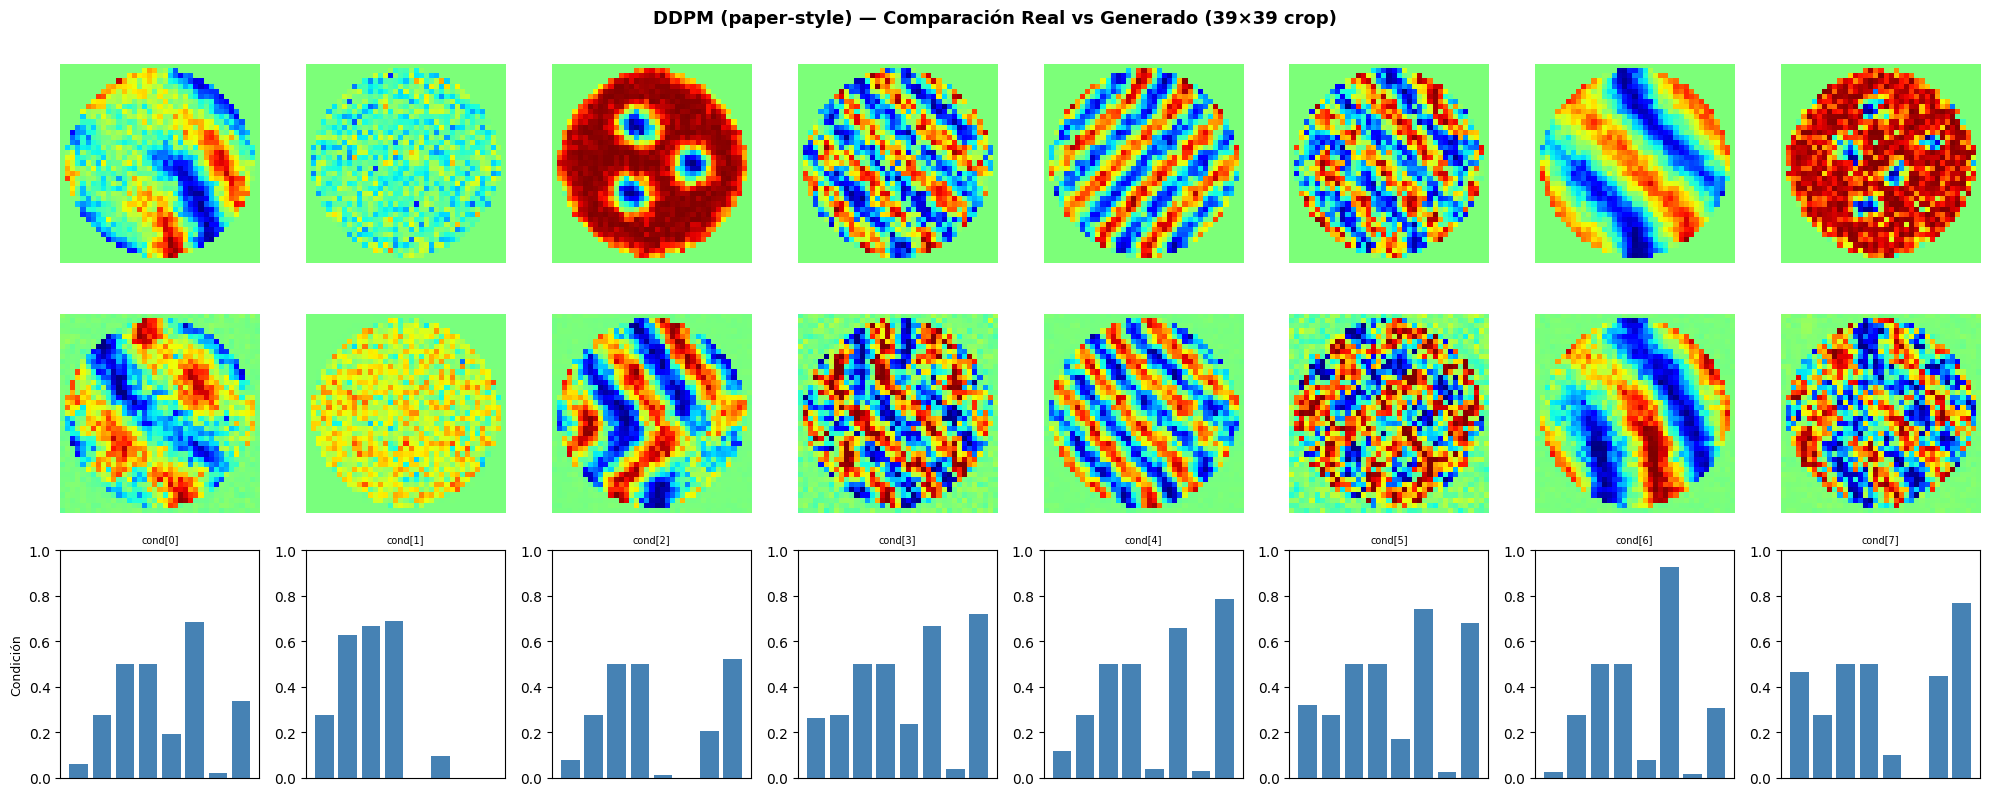


Métricas (n=8, crop 39×39):
  MAE  = 0.3945
  MSE  = 0.3568
  SSIM = 0.1356


In [12]:
# Cargar el mejor checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"Cargado checkpoint (época {ckpt['epoch']}, SSIM={ckpt['val_ssim']:.4f})")

n_show   = 8
dl_test = DataLoader(ds_test, batch_size=n_show, shuffle=True)
x_real_batch, cond_batch = next(iter(dl_test))
x_real_batch = x_real_batch[:n_show].to(DEVICE)
cond_batch   = cond_batch[:n_show].to(DEVICE)

print("Generando con 100 pasos (fast)...")
x_gen_fast = fast_sample(model, cond_batch, scheduler,
                         n_steps=100, img_size=IMG_SIZE)

# Crop a 39×39 para visualización y métricas
x_real_39 = crop_to_orig(x_real_batch)
x_gen_39  = crop_to_orig(x_gen_fast)

fig, axes = plt.subplots(3, n_show, figsize=(2.5 * n_show, 8))
fig.suptitle("DDPM (paper-style) — Comparación Real vs Generado (39×39 crop)",
             fontsize=13, fontweight='bold', y=0.99)

def to_np(t):
    return t.cpu().numpy()

for col in range(n_show):
    real = to_np(x_real_39[col, 0])
    gen  = to_np(x_gen_39[col, 0])

    for row, (im, label) in enumerate([
        (real, "Real"),
        (gen,  "Gen (100 pasos)"),
    ]):
        ax = axes[row, col]
        ax.imshow(im, cmap='jet', vmin=-1, vmax=1, interpolation='nearest')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=9)

    ax = axes[2, col]
    cond_np = cond_batch[col].cpu().numpy()
    ax.bar(range(COND_DIM), cond_np, color='steelblue')
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_title(f"cond[{col}]", fontsize=7)
    if col == 0:
        ax.set_ylabel("Condición", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/ddpm_paper_generations.png", dpi=120)
plt.show()

mae_f, mse_f, ssim_f = compute_metrics(x_gen_fast, x_real_batch)
print(f"\nMétricas (n={n_show}, crop 39×39):")
print(f"  MAE  = {mae_f:.4f}")
print(f"  MSE  = {mse_f:.4f}")
print(f"  SSIM = {ssim_f:.4f}")

## 12. Evaluación completa en test set

In [13]:
dl_test_full = DataLoader(ds_test, batch_size=32, shuffle=False, num_workers=2)

all_mae, all_mse, all_ssim = [], [], []

print(f"Evaluando {len(ds_test)} muestras test con fast sampler (100 pasos)...")
t_eval = time.time()

model.eval()
for i, (x0, cond) in enumerate(dl_test_full):
    x0   = x0.to(DEVICE)
    cond = cond.to(DEVICE)
    x_gen = fast_sample(model, cond, scheduler, n_steps=100, img_size=IMG_SIZE)
    mae, mse, s = compute_metrics(x_gen, x0)  # crop interno
    all_mae.append(mae); all_mse.append(mse); all_ssim.append(s)
    if (i + 1) % 5 == 0:
        print(f"  batch {i+1}/{len(dl_test_full)}  SSIM={s:.4f}")

print(f"\nEvaluación completada en {(time.time()-t_eval)/60:.1f} min")
print(f"\n{'='*60}")
print(f"RESUMEN FINAL — DDPM (paper-style)")
print(f"{'='*60}")
print(f"  MAE  test: {np.mean(all_mae):.4f} ± {np.std(all_mae):.4f}")
print(f"  MSE  test: {np.mean(all_mse):.4f} ± {np.std(all_mse):.4f}")
print(f"  SSIM test: {np.mean(all_ssim):.4f} ± {np.std(all_ssim):.4f}")
print(f"{'─'*60}")
print(f"  Nota: métricas calculadas sobre crop 39×39")
print(f"{'='*60}")

Evaluando 2546 muestras test con fast sampler (100 pasos)...
  batch 5/80  SSIM=-0.0023
  batch 10/80  SSIM=0.0230
  batch 15/80  SSIM=0.0340
  batch 20/80  SSIM=0.0642
  batch 25/80  SSIM=0.0599
  batch 30/80  SSIM=0.0711
  batch 35/80  SSIM=0.0267
  batch 40/80  SSIM=0.0999
  batch 45/80  SSIM=0.0202
  batch 50/80  SSIM=0.1050
  batch 55/80  SSIM=0.0189
  batch 60/80  SSIM=-0.0071
  batch 65/80  SSIM=0.0729
  batch 70/80  SSIM=0.0484
  batch 75/80  SSIM=-0.0156
  batch 80/80  SSIM=-0.0135

Evaluación completada en 5.9 min

RESUMEN FINAL — DDPM (paper-style)
  MAE  test: 0.4276 ± 0.0206
  MSE  test: 0.3921 ± 0.0300
  SSIM test: 0.0288 ± 0.0401
────────────────────────────────────────────────────────────
  Nota: métricas calculadas sobre crop 39×39


## 13. Guardar artefactos

In [14]:
# Mismo scaler para comparación justa
with open("/kaggle/working/param_scaler_ddpm_paper.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("/kaggle/working/history_ddpm_paper.json", "w") as f:
    json.dump(hist, f, indent=2)

summary_dict = {
    "model": "DDPM_PaperStyle",
    "params_M": round(n_params / 1e6, 3),
    "T_steps": T_STEPS,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "subsample": SUBSAMPLE_FRAC,
    "orig_size": ORIG_SIZE,
    "img_size": IMG_SIZE,
    "best_val_ssim": best_val_ssim,
    "test_mae_mean":  float(np.mean(all_mae)),
    "test_mae_std":   float(np.std(all_mae)),
    "test_mse_mean":  float(np.mean(all_mse)),
    "test_mse_std":   float(np.std(all_mse)),
    "test_ssim_mean": float(np.mean(all_ssim)),
    "test_ssim_std":  float(np.std(all_ssim)),
}
with open("/kaggle/working/ddpm_paper_metrics.json", "w") as f:
    json.dump(summary_dict, f, indent=2)

print("Artefactos guardados:")
print(f"  {CKPT_PATH}")
print(f"  {LAST_PATH}")
print(f"  /kaggle/working/param_scaler_ddpm_paper.pkl")
print(f"  /kaggle/working/history_ddpm_paper.json")
print(f"  /kaggle/working/ddpm_paper_metrics.json")
print(f"  /kaggle/working/ddpm_paper_curves.png")
print(f"  /kaggle/working/ddpm_paper_generations.png")

Artefactos guardados:
  /kaggle/working/ddpm_spines_paper_best.pt
  /kaggle/working/ddpm_spines_paper_last.pt
  /kaggle/working/param_scaler_ddpm_paper.pkl
  /kaggle/working/history_ddpm_paper.json
  /kaggle/working/ddpm_paper_metrics.json
  /kaggle/working/ddpm_paper_curves.png
  /kaggle/working/ddpm_paper_generations.png


## 14. Tabla comparativa: DDPM v1 vs DDPM (paper-style)

Carga las métricas del notebook v1 (`ddpm_metrics.json`) si están disponibles.

In [15]:
DDPM_V1_METRICS_PATH = "/kaggle/working/ddpm_metrics.json"

v1 = None
if os.path.exists(DDPM_V1_METRICS_PATH):
    with open(DDPM_V1_METRICS_PATH) as f:
        v1 = json.load(f)
    print(f"DDPM v1 cargado: SSIM={v1['test_ssim_mean']:.4f}  MAE={v1['test_mae_mean']:.4f}")
else:
    print("No se encontró ddpm_metrics.json del DDPM v1 — actualiza la ruta arriba")

print(f"\n{'='*70}")
print(f"COMPARACIÓN  DDPM v1 (ResBlocks)  vs  DDPM paper-style (Lee et al. 2025)")
print(f"{'─'*70}")
print(f"{'Métrica':<25} {'DDPM v1':>20} {'DDPM paper-style':>20}")
print(f"{'─'*70}")
v1_ssim = f"{v1['test_ssim_mean']:.4f}" if v1 else "  ?"
v1_mae  = f"{v1['test_mae_mean']:.4f}"  if v1 else "  ?"
v1_mse  = f"{v1['test_mse_mean']:.4f}"  if v1 else "  ?"
v1_par  = f"{v1['params_M']:.2f}"       if v1 else "  ?"
print(f"{'SSIM test':<25} {v1_ssim:>20} {np.mean(all_ssim):>20.4f}")
print(f"{'MAE test':<25} {v1_mae:>20} {np.mean(all_mae):>20.4f}")
print(f"{'MSE test':<25} {v1_mse:>20} {np.mean(all_mse):>20.4f}")
print(f"{'Params (M)':<25} {v1_par:>20} {n_params/1e6:>20.2f}")
print(f"{'='*70}")
print()
print("Notas:")
print("  - Ambos modelos usan EXACTAMENTE: seed=42, subsample=10%, split 70/15/15,")
print("    batch=64, lr=2e-4 constante, AdamW, T=1000, β lineal 1e-4→0.02,")
print("    50 épocas, fast sampler 100 pasos para validación y test.")
print("  - Diferencia: arquitectura U-Net (v1=ResBlocks/SiLU/3 niveles;")
print("    paper-style=Double Conv/GELU/4 niveles/embed sumado/attention en 2 niveles).")
print("  - Diferencia: v1 hacía resize bilinear 39→40; paper-style hace pad reflect y")
print("    métricas con crop 39×39.")

No se encontró ddpm_metrics.json del DDPM v1 — actualiza la ruta arriba

COMPARACIÓN  DDPM v1 (ResBlocks)  vs  DDPM paper-style (Lee et al. 2025)
──────────────────────────────────────────────────────────────────────
Métrica                                DDPM v1     DDPM paper-style
──────────────────────────────────────────────────────────────────────
SSIM test                                    ?               0.0288
MAE test                                     ?               0.4276
MSE test                                     ?               0.3921
Params (M)                                   ?                19.51

Notas:
  - Ambos modelos usan EXACTAMENTE: seed=42, subsample=10%, split 70/15/15,
    batch=64, lr=2e-4 constante, AdamW, T=1000, β lineal 1e-4→0.02,
    50 épocas, fast sampler 100 pasos para validación y test.
  - Diferencia: arquitectura U-Net (v1=ResBlocks/SiLU/3 niveles;
    paper-style=Double Conv/GELU/4 niveles/embed sumado/attention en 2 niveles).
  - Diferenc